# Multi-Coverage Position-Wise Accuracy Analysis
### Alphabet $\mathcal{A}_{11}$ (`2mix_3mix_4mix`, 15 classes) — EZ17 profile

**Goal.** Test whether the *edge > center* position-accuracy pattern persists
across coverage levels, and whether the Bi-LSTM's advantage over KL/ML is
larger in the center (which would indicate it exploits sequential context to
compensate for alignment-induced noise).

**Updated for the new (post-bug-fix) training pipeline.** Changes versus the
old version of this script:

| Aspect | Old script | This notebook (matches new training code) |
|---|---|---|
| Results directory | `./results_EZ17_2mix_3mix_4mix` | `./Results/{name}_{alphabet_mode}_H{H}_L{L}_lr{lr}_eps{eps}_seed{SEED}` |
| Weights file | `best_model_{name}_{alphabet}_M{M}.pth` | `best_model_M{M}.pth` |
| Train/val split | `random_split` after `set_seed` | deterministic SHA256(seed+filename+M) split, loaded from `split_indices_M{M}.pkl` |
| `MAX_COVERAGE` | 25 | **50** (matches `dataset_generator_uniform_composite.py`) |
| KL/ML epsilon | hard-coded `0.01` | per-profile `best_eps_klml` (EZ17 → 0.01) |
| Coverage sweep | `[10,15,20,25]` | `[25,15,10,5]` (intersection with the coverage levels the new training code actually trains: `[25,15,10,5,3,1]`) |

> **Note on coverage levels.** The new `train_evaluate_uniform_composite.py`
> trains `COVERAGE_LEVELS = [25, 15, 10, 5, 3, 1]`. The old M=20 weight does
> **not** exist in the re-run. The sweep below uses `[25, 15, 10, 5]`; any M
> without a `best_model_M{M}.pth` is skipped gracefully, so you can edit the
> list freely.


## Cell 1 — Imports & device

In [1]:
# =============================================================================
# CELL 1: IMPORTS & DEVICE
# =============================================================================
import os

# Pin GPU if needed (set to "" to let PyTorch choose)
DEVICE_ID = "3"
os.environ["CUDA_VISIBLE_DEVICES"] = DEVICE_ID

import random
import pickle
import json
import time
import hashlib
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
   GPU: NVIDIA GeForce RTX 3080


## Cell 2 — Configuration

`results_dir` is built with the **exact** formula
`train_evaluate_uniform_composite.py::make_config_for_profile` uses for its
`subdir`, so this notebook automatically finds the weights and split files
produced by the re-run training pipeline.


In [2]:
# =============================================================================
# CELL 2: CONFIGURATION
# =============================================================================

# ------------------- ANALYSIS TARGET -------------------
ERROR_MODEL   = "EZ17"
ALPHABET_MODE = "2mix_3mix_4mix"     # A_11 alphabet (15 classes)

# Coverage levels to sweep. Must be a subset of the training code's
COVERAGE_LEVELS = [25, 15, 10, 5, 1]

# ------------------- DATASET PARAMETERS (must match the generator) -------------------
NUM_SAMPLES  = 100000
MAX_COVERAGE = 50                    # <-- matches dataset_generator_uniform_composite.py
DATASET_DIR  = "./dataset"

# ------------------- TRAINING HYPERPARAMETERS -------------------
# Must match train_evaluate_uniform_composite.py (results dir depends on these).
HIDDEN_DIM    = 128
NUM_LAYERS    = 2
DROPOUT       = 0.2
BIDIRECTIONAL = True
BATCH_SIZE    = 500
LEARNING_RATE = 1e-3
SEED          = 42
TRAIN_FRACTION = 0.8

RESULTS_ROOT  = "./Results"

# ------------------- ANALYSIS PARAMETERS -------------------
EDGE_SIZE = 15        # number of positions counted as "edge" on each end

# ------------------- ERROR-MODEL SPECS -------------------
ERROR_MODEL_SPECS = {
    "EZ17":     {"seq_length": 136, "name": "EZ17", "best_eps_klml": 0.01},
    "G15":      {"seq_length": 104, "name": "G15",  "best_eps_klml": 0.05},
    "O17":      {"seq_length": 77,  "name": "O17",  "best_eps_klml": 0.01},
    "erlich":   {"seq_length": 136, "name": "EZ17", "best_eps_klml": 0.01},
    "grass":    {"seq_length": 104, "name": "G15",  "best_eps_klml": 0.05},
    "organick": {"seq_length": 77,  "name": "O17",  "best_eps_klml": 0.01},
}

VOCAB_SIZES = {"2mix_only": 10, "2mix_3mix": 14, "2mix_3mix_4mix": 15}
assert ALPHABET_MODE in VOCAB_SIZES, f"Unknown ALPHABET_MODE: {ALPHABET_MODE}"
assert ERROR_MODEL in ERROR_MODEL_SPECS, f"Unknown ERROR_MODEL: {ERROR_MODEL}"

_specs      = ERROR_MODEL_SPECS[ERROR_MODEL]
_error_name = _specs["name"]
_eps_klml   = _specs["best_eps_klml"]

# ----- Results sub-directory: IDENTICAL formula to the training script -----
_subdir = (f"{_error_name}_{ALPHABET_MODE}"
           f"_H{HIDDEN_DIM}_L{NUM_LAYERS}_lr{LEARNING_RATE:.0e}"
           f"_eps{_eps_klml:g}_seed{SEED}")

CONFIG = {
    "error_model":   ERROR_MODEL,
    "error_name":    _error_name,
    "alphabet_mode": ALPHABET_MODE,
    "vocab_size":    VOCAB_SIZES[ALPHABET_MODE],
    "seq_length":    _specs["seq_length"],

    "coverage_levels": list(COVERAGE_LEVELS),

    # Model architecture (must match training)
    "input_channels": 4,
    "hidden_dim":     HIDDEN_DIM,
    "num_layers":     NUM_LAYERS,
    "dropout":        DROPOUT,
    "bidirectional":  BIDIRECTIONAL,

    "batch_size":      BATCH_SIZE,
    "edge_size":       EDGE_SIZE,
    "train_fraction":  TRAIN_FRACTION,
    "seed":            SEED,
    "epsilon_klml":    _eps_klml,

    "results_dir":  os.path.join(RESULTS_ROOT, _subdir),
}

CONFIG["dataset_path"] = (f"{DATASET_DIR}/"
                          f"dna_{_error_name}_{ALPHABET_MODE}_"
                          f"{NUM_SAMPLES}_{MAX_COVERAGE}.pkl")

# Output directory for this position analysis
CONFIG["output_dir"] = os.path.join(
    "./position_analysis_multi_coverage", _subdir)
os.makedirs(CONFIG["output_dir"], exist_ok=True)

print("=" * 64)
print(" MULTI-COVERAGE POSITION ANALYSIS CONFIGURATION")
print("=" * 64)
print(f"   Error model     : {CONFIG['error_name']}")
print(f"   Alphabet        : {CONFIG['alphabet_mode']} ({CONFIG['vocab_size']} classes)")
print(f"   Coverage levels : {CONFIG['coverage_levels']}")
print(f"   Sequence length : {CONFIG['seq_length']}")
print(f"   Edge size       : {CONFIG['edge_size']} positions per end")
print(f"   KL/ML epsilon   : {CONFIG['epsilon_klml']:g}")
print(f"   Dataset path    : {CONFIG['dataset_path']}")
print(f"   Results dir     : {CONFIG['results_dir']}")
print(f"   Output dir      : {CONFIG['output_dir']}")
print("=" * 64)

 MULTI-COVERAGE POSITION ANALYSIS CONFIGURATION
   Error model     : EZ17
   Alphabet        : 2mix_3mix_4mix (15 classes)
   Coverage levels : [25, 15, 10, 5, 1]
   Sequence length : 136
   Edge size       : 15 positions per end
   KL/ML epsilon   : 0.01
   Dataset path    : ./dataset/dna_EZ17_2mix_3mix_4mix_100000_50.pkl
   Results dir     : ./Results/EZ17_2mix_3mix_4mix_H128_L2_lr1e-03_eps0.01_seed42
   Output dir      : ./position_analysis_multi_coverage/EZ17_2mix_3mix_4mix_H128_L2_lr1e-03_eps0.01_seed42


## Cell 3 — Seed helpers (replicated verbatim from the training script)

In [3]:
# =============================================================================
# CELL 3: SEED HELPERS  (verbatim from train_evaluate_uniform_composite.py)
# =============================================================================
def set_global_seed(seed):
    """Seed Python random, numpy, and torch (CPU+CUDA). Disables non-determinism."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def split_seed_for(base_seed, dataset_path, coverage_M):
    """Deterministic split seed from (base_seed, dataset filename, M).
    Identical to the training code."""
    key = f"{base_seed}|{os.path.basename(dataset_path)}|M{coverage_M}"
    h = hashlib.sha256(key.encode("utf-8")).digest()
    return int.from_bytes(h[:4], byteorder="big", signed=False)


set_global_seed(CONFIG["seed"])
print(f"Global seed set to {CONFIG['seed']}.")

Global seed set to 42.


## Cell 4 — Symbol mappings & ideal vectors

In [4]:
# =============================================================================
# CELL 4: SYMBOL MAPPINGS & IDEAL VECTORS
# =============================================================================
def build_symbol_to_idx(mode):
    s = {'A': 0, 'C': 1, 'G': 2, 'T': 3,
         'M1': 4, 'M2': 5, 'M3': 6, 'M4': 7, 'M5': 8, 'M6': 9}
    if mode in ("2mix_3mix", "2mix_3mix_4mix"):
        s.update({'T1': 10, 'T2': 11, 'T3': 12, 'T4': 13})
    if mode == "2mix_3mix_4mix":
        s.update({'Q1': 14})
    return s


def build_ideal_vectors(mode):
    vecs = [
        [1.0, 0.0, 0.0, 0.0],  # A
        [0.0, 1.0, 0.0, 0.0],  # C
        [0.0, 0.0, 1.0, 0.0],  # G
        [0.0, 0.0, 0.0, 1.0],  # T
        [0.5, 0.0, 0.0, 0.5],  # M1 A|T
        [0.0, 0.5, 0.5, 0.0],  # M2 C|G
        [0.0, 0.5, 0.0, 0.5],  # M3 C|T
        [0.0, 0.0, 0.5, 0.5],  # M4 G|T
        [0.5, 0.5, 0.0, 0.0],  # M5 A|C
        [0.5, 0.0, 0.5, 0.0],  # M6 A|G
    ]
    if mode in ("2mix_3mix", "2mix_3mix_4mix"):
        t = 1.0 / 3.0
        vecs += [[t, t, t, 0.0], [t, t, 0.0, t], [t, 0.0, t, t], [0.0, t, t, t]]
    if mode == "2mix_3mix_4mix":
        vecs.append([0.25, 0.25, 0.25, 0.25])
    return torch.tensor(vecs, dtype=torch.float32)


SYMBOL_TO_IDX = build_symbol_to_idx(CONFIG["alphabet_mode"])
IDX_TO_SYMBOL = {v: k for k, v in SYMBOL_TO_IDX.items()}
IDEAL_VECTORS = build_ideal_vectors(CONFIG["alphabet_mode"]).to(device)

print(f"Alphabet '{CONFIG['alphabet_mode']}': {len(SYMBOL_TO_IDX)} symbols.")

Alphabet '2mix_3mix_4mix': 15 symbols.


## Cell 5 — Data preprocessing & dataset class

In [5]:
# =============================================================================
# CELL 5: DATA PREPROCESSING & DATASET CLASS
# =============================================================================
def preprocess_cluster_to_matrix(cluster_reads, target_length):
    """Map a cluster of variable-length noisy reads to a (4, target_length)
    normalised nucleotide-frequency matrix via linear alignment. Identical to
    the training-script implementation."""
    profile_matrix = np.zeros((4, target_length), dtype=np.float32)
    base_map = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    num_reads = len(cluster_reads)

    for read in cluster_reads:
        read_len = len(read)
        if read_len == 0:
            continue
        for t_idx in range(target_length):
            read_idx = int((t_idx + 0.5) * (read_len / target_length))
            if read_idx >= read_len:
                read_idx = read_len - 1
            base = read[read_idx]
            if base in base_map:
                profile_matrix[base_map[base], t_idx] += 1.0

    if num_reads > 0:
        profile_matrix /= num_reads
    return profile_matrix


class CompositeDNADataset(Dataset):
    """PyTorch dataset for composite-DNA pickles. Identical to the
    training-script class."""

    def __init__(self, data_path, seq_length, symbol_to_idx, limit_coverage=None):
        with open(data_path, 'rb') as f:
            raw = pickle.load(f)
        self.samples = raw['data']
        self.metadata = raw.get('metadata', {})
        self.seq_length = seq_length
        self.symbol_to_idx = symbol_to_idx
        self.limit_coverage = limit_coverage

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        cluster = item['cluster']
        if self.limit_coverage is not None:
            actual = min(self.limit_coverage, len(cluster))
            cluster = cluster[:actual]
        x = preprocess_cluster_to_matrix(cluster, self.seq_length)
        y = np.array([self.symbol_to_idx[s] for s in item['label']], dtype=np.longlong)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)


print("Dataset class ready.")

Dataset class ready.


## Cell 6 — Reproducible train/val split

Replicated verbatim from `train_evaluate_uniform_composite.py`. This is what
guarantees the validation set analysed here is **identical** to the one the
network was early-stopped on at each coverage level.


In [6]:
# =============================================================================
# CELL 6: REPRODUCIBLE TRAIN/VAL SPLIT  (verbatim from training script)
# =============================================================================
def make_reproducible_split(full_ds, base_seed, dataset_path, coverage_M,
                            train_frac=0.8, split_dir=None):
    """Return (train_subset, val_subset, split_seed). Loads a saved
    split_indices_M{M}.pkl if present (guaranteeing eval == training split),
    else recomputes the identical deterministic split."""
    n = len(full_ds)
    n_train = int(train_frac * n)

    split_seed = split_seed_for(base_seed, dataset_path, coverage_M)
    split_file = None
    if split_dir is not None:
        split_file = os.path.join(split_dir, f"split_indices_M{coverage_M}.pkl")

    if split_file is not None and os.path.exists(split_file):
        with open(split_file, 'rb') as f:
            saved = pickle.load(f)
        if saved['seed'] == split_seed and saved['n'] == n:
            print(f"      Loaded saved train/val split from {split_file}")
            return (Subset(full_ds, saved['train_idx']),
                    Subset(full_ds, saved['val_idx']), split_seed)
        else:
            print(f"      [WARN] saved split mismatch -- recomputing")

    rng = np.random.RandomState(split_seed)
    perm = rng.permutation(n)
    train_idx = perm[:n_train].tolist()
    val_idx = perm[n_train:].tolist()
    print(f"      Recomputed deterministic split (split_seed={split_seed})")
    return (Subset(full_ds, train_idx),
            Subset(full_ds, val_idx), split_seed)


print("Split helper ready.")

Split helper ready.


## Cell 7 — Bi-LSTM model

In [7]:
# =============================================================================
# CELL 7: BI-LSTM MODEL
# =============================================================================
class CompositeDecoderLSTM(nn.Module):
    """Bi-LSTM decoder.  Input (B,4,L) -> Output (B,V,L). Identical to the
    training-script architecture."""

    def __init__(self, config):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=config['input_channels'],
            hidden_size=config['hidden_dim'],
            num_layers=config['num_layers'],
            batch_first=True,
            bidirectional=config['bidirectional'],
            dropout=config['dropout'] if config['num_layers'] > 1 else 0.0,
        )
        fc_in = config['hidden_dim'] * 2 if config['bidirectional'] else config['hidden_dim']
        self.fc = nn.Linear(fc_in, config['vocab_size'])

    def forward(self, x):
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        logits = self.fc(out)
        return logits.permute(0, 2, 1)


print("Model class ready.")

Model class ready.


## Cell 8 — Baseline decoders

In [8]:
# =============================================================================
# CELL 8: BASELINE DECODERS
# =============================================================================
def min_distance_decoder(obs, ideal_vectors):
    """Min-Euclidean-distance decoder."""
    dists = torch.sum(
        (obs.unsqueeze(2) - ideal_vectors.unsqueeze(0).unsqueeze(0)) ** 2, dim=3)
    return torch.argmin(dists, dim=2)


def kl_divergence_decoder(obs, ideal_vectors, epsilon):
    """KL-divergence decoder with smoothed ideals."""
    ideal_safe = torch.clamp(ideal_vectors.clone(), min=epsilon)
    ideal_safe = ideal_safe / ideal_safe.sum(dim=-1, keepdim=True)
    obs_expanded = obs.unsqueeze(2)
    log_ideal = torch.log(ideal_safe).unsqueeze(0).unsqueeze(0)
    ce = -(obs_expanded * log_ideal).sum(dim=-1)
    return torch.argmin(ce, dim=-1)


print(f"Baseline decoders ready (KL epsilon = {CONFIG['epsilon_klml']:g}).")

Baseline decoders ready (KL epsilon = 0.01).


## Cell 9 — Position-wise accuracy & region analysis

`compute_position_wise_accuracy` returns per-position accuracy (%) for each
decoder. `analyze_regions` splits positions into *edge* (`EDGE_SIZE` per end)
and *center*, and reports the center-minus-edge gap.


In [9]:
# =============================================================================
# CELL 9: POSITION-WISE ACCURACY & REGION ANALYSIS
# =============================================================================
def compute_position_wise_accuracy(model, loader, ideal_vectors, device,
                                   seq_length, epsilon_klml):
    """Per-position accuracy (%) for Bi-LSTM, Min-Distance and KL decoders."""
    model.eval()
    correct_lstm    = np.zeros(seq_length)
    correct_mindist = np.zeros(seq_length)
    correct_kl      = np.zeros(seq_length)
    total_per_pos   = np.zeros(seq_length)

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            batch_size = inputs.size(0)
            obs = inputs.permute(0, 2, 1)

            pred_lstm    = torch.argmax(model(inputs), dim=1)
            pred_mindist = min_distance_decoder(obs, ideal_vectors)
            pred_kl      = kl_divergence_decoder(obs, ideal_vectors, epsilon_klml)

            labels_np  = labels.cpu().numpy()
            lstm_np    = pred_lstm.cpu().numpy()
            mindist_np = pred_mindist.cpu().numpy()
            kl_np      = pred_kl.cpu().numpy()

            correct_lstm    += np.sum(lstm_np    == labels_np, axis=0)
            correct_mindist += np.sum(mindist_np == labels_np, axis=0)
            correct_kl      += np.sum(kl_np      == labels_np, axis=0)
            total_per_pos   += batch_size

    return {
        'lstm':      100.0 * correct_lstm    / total_per_pos,
        'mindist':   100.0 * correct_mindist / total_per_pos,
        'kl':        100.0 * correct_kl      / total_per_pos,
        'positions': np.arange(seq_length),
    }


def analyze_regions(position_accuracies, edge_size, seq_length):
    """Split into edge / center regions and report the center-minus-edge gap."""
    edge_positions = (list(range(0, edge_size))
                      + list(range(seq_length - edge_size, seq_length)))
    center_positions = list(range(edge_size, seq_length - edge_size))

    results = {}
    for decoder in ['lstm', 'mindist', 'kl']:
        acc = position_accuracies[decoder]
        edge_acc   = float(np.mean(acc[edge_positions]))
        center_acc = float(np.mean(acc[center_positions]))
        overall    = float(np.mean(acc))
        results[decoder] = {
            'edge':   edge_acc,
            'center': center_acc,
            'overall': overall,
            'center_minus_edge': center_acc - edge_acc,
        }
    return results


print("Position-wise analysis routines ready.")

Position-wise analysis routines ready.


## Cell 10 — Main sweep over coverage levels

For each coverage M the notebook: loads the dataset capped at M, reproduces the
identical validation split, loads `best_model_M{M}.pth`, computes per-position
accuracy and the edge/center region split. Coverage levels with no saved
weights are skipped.


In [10]:
# =============================================================================
# CELL 10: MAIN SWEEP OVER COVERAGE LEVELS
# =============================================================================
print("=" * 70)
print(" MULTI-COVERAGE POSITION-WISE ANALYSIS")
print("=" * 70)

if not os.path.exists(CONFIG['dataset_path']):
    raise FileNotFoundError(
        f"Dataset not found: {CONFIG['dataset_path']}\n"
        f"  Run dataset_generator_uniform_composite.py first.")

all_results = {}

for coverage in CONFIG['coverage_levels']:
    model_path = os.path.join(
        CONFIG['results_dir'], f"best_model_M{coverage}.pth")

    if not os.path.exists(model_path):
        print(f"\n[skip] Model not found for M={coverage}: {model_path}")
        continue

    print(f"\n{'='*60}")
    print(f" ANALYZING COVERAGE M = {coverage}")
    print(f"{'='*60}")

    # --- dataset (capped at this coverage) ---
    set_global_seed(CONFIG['seed'])
    full_ds = CompositeDNADataset(
        CONFIG['dataset_path'], CONFIG['seq_length'],
        SYMBOL_TO_IDX, limit_coverage=coverage)

    # --- reproducible validation split (identical to training) ---
    _, val_ds, split_seed = make_reproducible_split(
        full_ds, base_seed=CONFIG['seed'],
        dataset_path=CONFIG['dataset_path'],
        coverage_M=coverage,
        train_frac=CONFIG['train_fraction'],
        split_dir=CONFIG['results_dir'])
    val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'],
                            shuffle=False, num_workers=0)
    print(f"   Val set: {len(val_ds):,} samples (split_seed={split_seed})")

    # --- model ---
    model = CompositeDecoderLSTM(CONFIG).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # --- position-wise accuracy + region analysis ---
    t0 = time.time()
    position_accuracies = compute_position_wise_accuracy(
        model, val_loader, IDEAL_VECTORS, device,
        CONFIG['seq_length'], CONFIG['epsilon_klml'])
    region_results = analyze_regions(
        position_accuracies, CONFIG['edge_size'], CONFIG['seq_length'])
    print(f"   Computed in {time.time() - t0:.1f}s")

    all_results[coverage] = {
        'position_accuracies': {
            k: (v.tolist() if isinstance(v, np.ndarray) else v)
            for k, v in position_accuracies.items()},
        'region_results': region_results,
        'split_seed': int(split_seed),
        'val_size': len(val_ds),
    }

    print(f"\n   {'Decoder':<15} {'Edge':<10} {'Center':<10} "
          f"{'Overall':<10} {'D(C-E)':<10}")
    print(f"   {'-'*55}")
    for decoder in ['lstm', 'kl', 'mindist']:
        r = region_results[decoder]
        name = {'lstm': 'Bi-LSTM', 'kl': 'KL/ML',
                'mindist': 'Min. Distance'}[decoder]
        print(f"   {name:<15} {r['edge']:<10.2f} {r['center']:<10.2f} "
              f"{r['overall']:<10.2f} {r['center_minus_edge']:+.2f}")

if not all_results:
    raise RuntimeError(
        "No coverage level had saved weights. Check CONFIG['results_dir'] "
        "and that train_evaluate_uniform_composite.py has been run.")

 MULTI-COVERAGE POSITION-WISE ANALYSIS

 ANALYZING COVERAGE M = 25
      Loaded saved train/val split from ./Results/EZ17_2mix_3mix_4mix_H128_L2_lr1e-03_eps0.01_seed42/split_indices_M25.pkl
   Val set: 20,000 samples (split_seed=213851671)
   Computed in 138.9s

   Decoder         Edge       Center     Overall    D(C-E)    
   -------------------------------------------------------
   Bi-LSTM         99.64      98.72      98.92      -0.92
   KL/ML           99.28      92.84      94.26      -6.44
   Min. Distance   93.52      93.30      93.34      -0.22

 ANALYZING COVERAGE M = 15
      Loaded saved train/val split from ./Results/EZ17_2mix_3mix_4mix_H128_L2_lr1e-03_eps0.01_seed42/split_indices_M15.pkl
   Val set: 20,000 samples (split_seed=264335643)
   Computed in 82.8s

   Decoder         Edge       Center     Overall    D(C-E)    
   -------------------------------------------------------
   Bi-LSTM         97.99      95.09      95.73      -2.90
   KL/ML           95.78      89.28   

## Cell 11 — Summary comparison: edge vs center across coverage

In [11]:
# =============================================================================
# CELL 11: SUMMARY -- EDGE VS CENTER ACROSS COVERAGE LEVELS
# =============================================================================
print("=" * 80)
print(" SUMMARY: EDGE VS CENTER ACROSS COVERAGE LEVELS")
print("=" * 80)

print(f"\n{'Coverage':<10} | {'Bi-LSTM':<25} | {'KL/ML':<25} | {'Min. Distance':<25}")
print(f"{'':<10} | {'Edge':>8} {'Center':>8} {'D':>7} | "
      f"{'Edge':>8} {'Center':>8} {'D':>7} | "
      f"{'Edge':>8} {'Center':>8} {'D':>7}")
print(f"{'-'*95}")

for coverage in CONFIG['coverage_levels']:
    if coverage not in all_results:
        continue
    r = all_results[coverage]['region_results']
    lstm, kl, mindist = r['lstm'], r['kl'], r['mindist']
    print(f"M={coverage:<7} | "
          f"{lstm['edge']:>8.2f} {lstm['center']:>8.2f} {lstm['center_minus_edge']:>+7.2f} | "
          f"{kl['edge']:>8.2f} {kl['center']:>8.2f} {kl['center_minus_edge']:>+7.2f} | "
          f"{mindist['edge']:>8.2f} {mindist['center']:>8.2f} {mindist['center_minus_edge']:>+7.2f}")

 SUMMARY: EDGE VS CENTER ACROSS COVERAGE LEVELS

Coverage   | Bi-LSTM                   | KL/ML                     | Min. Distance            
           |     Edge   Center       D |     Edge   Center       D |     Edge   Center       D
-----------------------------------------------------------------------------------------------
M=25      |    99.64    98.72   -0.92 |    99.28    92.84   -6.44 |    93.52    93.30   -0.22
M=15      |    97.99    95.09   -2.90 |    95.78    89.28   -6.49 |    89.98    87.34   -2.64
M=10      |    94.81    89.58   -5.22 |    88.42    80.70   -7.72 |    82.00    78.86   -3.14
M=5       |    79.82    73.27   -6.54 |    78.75    66.23  -12.52 |    68.18    62.27   -5.91
M=1       |    26.38    24.97   -1.41 |    26.38    24.97   -1.41 |    26.38    24.97   -1.41


## Cell 12 — Key insights

In [12]:
# =============================================================================
# CELL 12: KEY INSIGHTS
# =============================================================================
print("=" * 80)
print(" KEY INSIGHTS")
print("=" * 80)

# --- 1. Does the Edge > Center pattern persist? ---
edge_gt_center_count = 0
total_count = 0
for coverage in CONFIG['coverage_levels']:
    if coverage not in all_results:
        continue
    for decoder in ['lstm', 'kl', 'mindist']:
        r = all_results[coverage]['region_results'][decoder]
        if r['edge'] > r['center']:
            edge_gt_center_count += 1
        total_count += 1

print(f"\n1. Edge > Center pattern:")
print(f"   Occurs in {edge_gt_center_count}/{total_count} cases "
      f"({100 * edge_gt_center_count / total_count:.0f}%)")

# --- 2. Bi-LSTM advantage by region ---
print(f"\n2. Bi-LSTM advantage (over KL/ML) by region:")
print(f"   {'Coverage':<10} {'Edge Adv.':<15} {'Center Adv.':<15} "
      f"{'Center > Edge?':<15}")
print(f"   {'-'*55}")

available = [c for c in CONFIG['coverage_levels'] if c in all_results]
center_advantage_higher = 0
for coverage in available:
    r = all_results[coverage]['region_results']
    edge_adv   = r['lstm']['edge']   - r['kl']['edge']
    center_adv = r['lstm']['center'] - r['kl']['center']
    higher = "YES" if center_adv > edge_adv else "NO"
    if center_adv > edge_adv:
        center_advantage_higher += 1
    print(f"   M={coverage:<7} {edge_adv:>+10.2f}%    "
          f"{center_adv:>+10.2f}%    {higher}")

print(f"\n   Bi-LSTM advantage larger in center: "
      f"{center_advantage_higher}/{len(available)} coverage levels")

 KEY INSIGHTS

1. Edge > Center pattern:
   Occurs in 15/15 cases (100%)

2. Bi-LSTM advantage (over KL/ML) by region:
   Coverage   Edge Adv.       Center Adv.     Center > Edge? 
   -------------------------------------------------------
   M=25           +0.36%         +5.88%    YES
   M=15           +2.21%         +5.81%    YES
   M=10           +6.39%         +8.88%    YES
   M=5            +1.06%         +7.04%    YES
   M=1            +0.00%         +0.00%    NO

   Bi-LSTM advantage larger in center: 4/5 coverage levels


## Cell 13 — Conclusion & save results

In [13]:
# =============================================================================
# CELL 13: CONCLUSION & SAVE RESULTS
# =============================================================================
print("=" * 80)
print(" CONCLUSION")
print("=" * 80)

if total_count > 0 and edge_gt_center_count == total_count:
    print("\n- Edge > Center pattern is UNIVERSAL (all decoders, all coverage levels)")
    print("  -> attributable to ALIGNMENT / PREPROCESSING, not decoder-specific")

if available and center_advantage_higher >= len(available) / 2:
    print("\n- Bi-LSTM advantage is LARGER in CENTER than at EDGES")
    print("  -> indicates the Bi-LSTM uses SEQUENTIAL CONTEXT to compensate for")
    print("     alignment-induced noise in the harder center positions")

# Attach run metadata before saving.
save_payload = {
    'config': {
        'error_name':      CONFIG['error_name'],
        'alphabet_mode':   CONFIG['alphabet_mode'],
        'vocab_size':      CONFIG['vocab_size'],
        'seq_length':      CONFIG['seq_length'],
        'edge_size':       CONFIG['edge_size'],
        'epsilon_klml':    CONFIG['epsilon_klml'],
        'results_dir':     CONFIG['results_dir'],
        'coverage_levels': CONFIG['coverage_levels'],
        'seed':            CONFIG['seed'],
        'timestamp':       datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    },
    'per_coverage': all_results,
}

results_path = os.path.join(CONFIG['output_dir'], 'multi_coverage_results.json')
with open(results_path, 'w') as f:
    json.dump(save_payload, f, indent=4)
print(f"\nResults saved: {results_path}")

 CONCLUSION

- Edge > Center pattern is UNIVERSAL (all decoders, all coverage levels)
  -> attributable to ALIGNMENT / PREPROCESSING, not decoder-specific

- Bi-LSTM advantage is LARGER in CENTER than at EDGES
  -> indicates the Bi-LSTM uses SEQUENTIAL CONTEXT to compensate for
     alignment-induced noise in the harder center positions

Results saved: ./position_analysis_multi_coverage/EZ17_2mix_3mix_4mix_H128_L2_lr1e-03_eps0.01_seed42/multi_coverage_results.json


## Cell 14 — Plot: center − edge gap by coverage

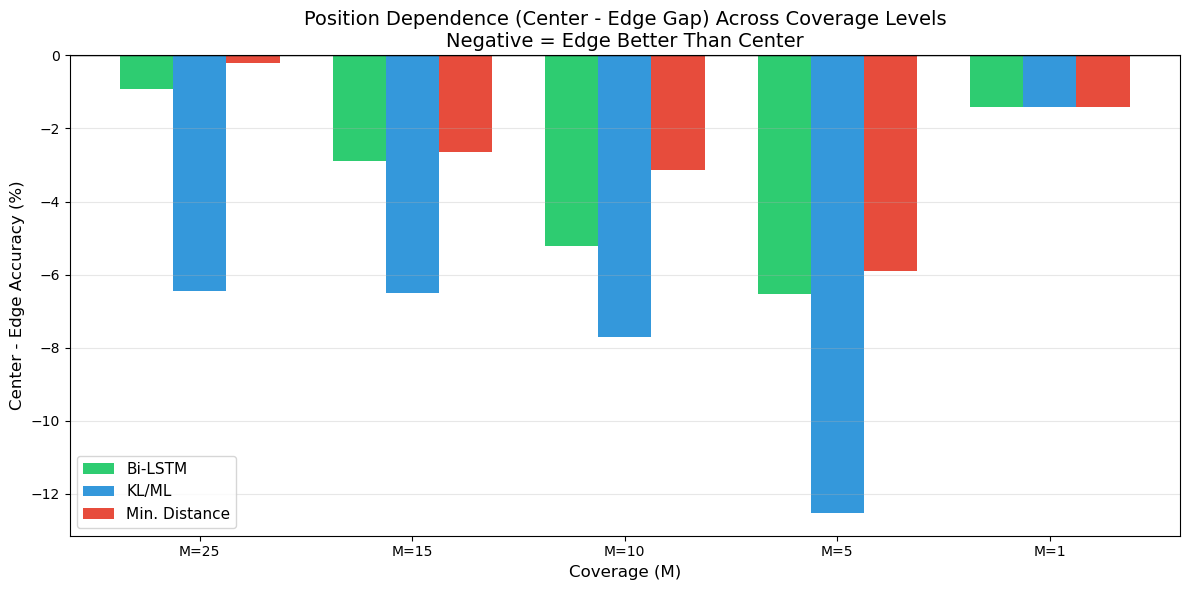

Plot saved: ./position_analysis_multi_coverage/EZ17_2mix_3mix_4mix_H128_L2_lr1e-03_eps0.01_seed42/edge_center_gap_by_coverage.png


In [14]:
# =============================================================================
# CELL 14: PLOT -- CENTER-MINUS-EDGE GAP BY COVERAGE
# =============================================================================
coverages = [c for c in CONFIG['coverage_levels'] if c in all_results]
lstm_gaps    = [all_results[c]['region_results']['lstm']['center_minus_edge']    for c in coverages]
kl_gaps      = [all_results[c]['region_results']['kl']['center_minus_edge']      for c in coverages]
mindist_gaps = [all_results[c]['region_results']['mindist']['center_minus_edge'] for c in coverages]

x = np.arange(len(coverages))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, lstm_gaps,    width, label='Bi-LSTM',       color='#2ecc71')
plt.bar(x,         kl_gaps,      width, label='KL/ML',         color='#3498db')
plt.bar(x + width, mindist_gaps, width, label='Min. Distance', color='#e74c3c')

plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.xlabel('Coverage (M)', fontsize=12)
plt.ylabel('Center - Edge Accuracy (%)', fontsize=12)
plt.title('Position Dependence (Center - Edge Gap) Across Coverage Levels\n'
          'Negative = Edge Better Than Center', fontsize=14)
plt.xticks(x, [f'M={c}' for c in coverages])
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

plot_path = os.path.join(CONFIG['output_dir'], 'edge_center_gap_by_coverage.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Plot saved: {plot_path}")

## Cell 15 — Plot: Bi-LSTM advantage by region

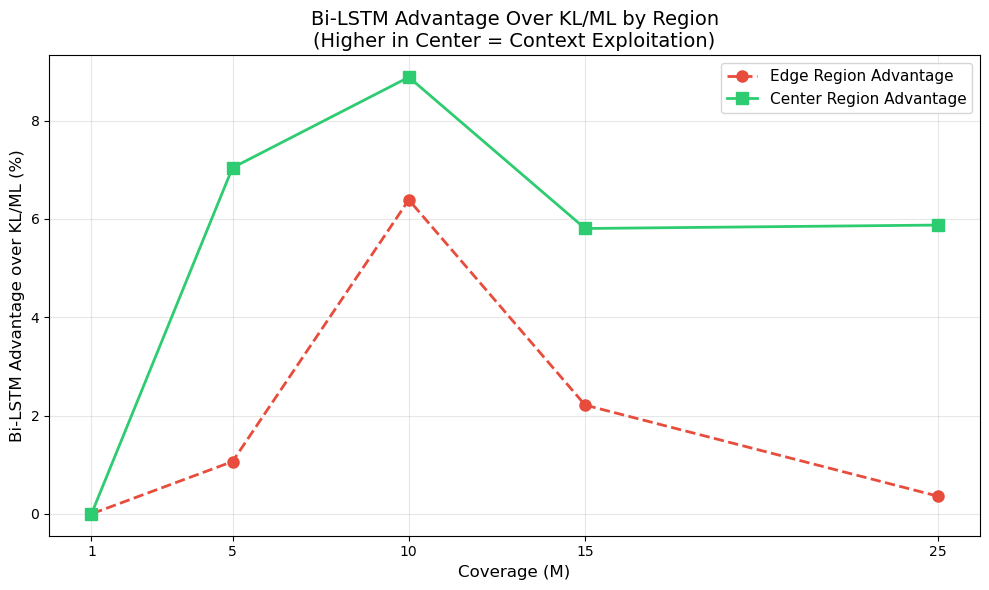

Plot saved: ./position_analysis_multi_coverage/EZ17_2mix_3mix_4mix_H128_L2_lr1e-03_eps0.01_seed42/bilstm_advantage_by_region.png

 ANALYSIS COMPLETE
   All results saved to: ./position_analysis_multi_coverage/EZ17_2mix_3mix_4mix_H128_L2_lr1e-03_eps0.01_seed42


In [15]:
# =============================================================================
# CELL 15: PLOT -- BI-LSTM ADVANTAGE BY REGION
# =============================================================================
edge_advs = [all_results[c]['region_results']['lstm']['edge']
             - all_results[c]['region_results']['kl']['edge'] for c in coverages]
center_advs = [all_results[c]['region_results']['lstm']['center']
               - all_results[c]['region_results']['kl']['center'] for c in coverages]

plt.figure(figsize=(10, 6))
plt.plot(coverages, edge_advs, 'o--', lw=2, ms=8, color='#e74c3c',
         label='Edge Region Advantage')
plt.plot(coverages, center_advs, 's-', lw=2, ms=8, color='#2ecc71',
         label='Center Region Advantage')

plt.xlabel('Coverage (M)', fontsize=12)
plt.ylabel('Bi-LSTM Advantage over KL/ML (%)', fontsize=12)
plt.title('Bi-LSTM Advantage Over KL/ML by Region\n'
          '(Higher in Center = Context Exploitation)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(coverages)
plt.tight_layout()

plot_path = os.path.join(CONFIG['output_dir'], 'bilstm_advantage_by_region.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Plot saved: {plot_path}")

print("\n" + "=" * 70)
print(" ANALYSIS COMPLETE")
print(f"   All results saved to: {CONFIG['output_dir']}")
print("=" * 70)